In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Membaca file '/content/Dataset .xlsx'

Kita akan membaca dataset menggunakan `pandas.read_excel()`.

In [ ]:
# Membaca file Excel
df = pd.read_excel('/content/Dataset .xlsx')

# Menampilkan 5 baris pertama dan informasi kolom untuk inspeksi awal
print("First 5 rows of the dataset:")
display(df.head())
print("\nDataset info:")
df.info()

First 5 rows of the dataset:


,Timestamp,Nama Lengkap,Jenis Kelamin,Usia,"Pertanyaan 1: Format konten apa yang paling sering direkomendasikan oleh algoritma di tab ""Explore"" atau ""Reels"" Anda saat ini?",Pertanyaan 2: Seberapa sering algoritma Instagram merekomendasikan konten dari akun yang tidak Anda ikuti (unfollowed) di Beranda utama?,"Pertanyaan 3: Jika Anda berlama-lama melihat sebuah video (menonton sampai habis), apakah setelah itu konten sejenis langsung mendominasi rekomendasi Anda?",Pertanyaan 4: Tindakan apa yang paling sering membuat algoritma mengubah total topik rekomendasi di Instagram Anda?,Pertanyaan 5: Seberapa akurat algoritma Instagram dalam merekomendasikan konten yang sesuai dengan hobi atau minat Anda saat ini?,Pertanyaan 6: Apakah Anda merasa algoritma Instagram sering merekomendasikan konten yang menggunakan lagu/audio yang sedang viral/tren?,Pertanyaan 7: Berapa lama biasanya Anda terjebak melihat konten-konten rekomendasi (scrolling di Reels/Explore) dalam sekali buka aplikasi?,"Pertanyaan 8: Ketika Anda menekan tombol ""Save"" (Simpan) pada suatu konten, apakah algoritma akan memperbanyak konten serupa di hari berikutnya?","Pertanyaan 9: Apakah Anda pernah menggunakan fitur ""Not Interested"" (Tidak Tertarik) untuk menyaring rekomendasi algoritma yang tidak disukai?","Pertanyaan 10: Berdasarkan pengalaman Anda, konten rekomendasi dari daerah mana yang paling sering muncul di akun Anda?"
0,2026-05-26 11:21:07.295,Abdian al hakim,Laki-Laki,18-25 Tahun,Foto Tunggal (Single Post),Kadang-kadang (Ada beberapa postingan rekomend...,Iya langsung berpengaruh saat itu juga (Algori...,Melakukan pencarian (Searching) kata kunci ata...,"Cukup akurat (Kadang sesuai, kadang tidak)",Kadang-kadang saja,Sebentar saja (< 10 menit),"Iya, jumlah rekomendasi konten sejenis sedikit...","Pernah, dan algoritma langsung berhenti mereko...",Konten nasional (Satu Indonesia)
1,2026-05-26 12:26:07.201,muhammad hammam,Laki-Laki,18-25 Tahun,Video Pendek (Reels),Kadang-kadang (Ada beberapa postingan rekomend...,"Iya berpengaruh, tapi butuh waktu beberapa hari",Melakukan pencarian (Searching) kata kunci ata...,"Cukup akurat (Kadang sesuai, kadang tidak)",Kadang-kadang saja,Sebentar saja (< 10 menit),"Iya, jumlah rekomendasi konten sejenis sedikit...","Pernah, tapi algoritmanya tetap memunculkan ko...",Konten nasional (Satu Indonesia)
2,2026-05-26 17:54:57.127,Muhammad Rayhan Mumtaz,Laki-Laki,18-25 Tahun,Video Pendek (Reels),Sangat Sering (Beranda penuh dengan postingan ...,Iya langsung berpengaruh saat itu juga (Algori...,Memberikan Like pada postingan bertopik baru,"Cukup akurat (Kadang sesuai, kadang tidak)","Iya, hampir semua rekomendasi Reels menggunaka...",Sedang (10 - 30 menit),"Iya, jumlah rekomendasi konten sejenis sedikit...","Pernah, dan algoritma langsung berhenti mereko...",Konten lokal/regional terdekat saja (Berbasis ...
3,2026-05-26 18:05:39.386,Fadliyan Rizky Noverio,Laki-Laki,18-25 Tahun,Video Pendek (Reels),Sangat Sering (Beranda penuh dengan postingan ...,Iya langsung berpengaruh saat itu juga (Algori...,Melakukan pencarian (Searching) kata kunci ata...,"Cukup akurat (Kadang sesuai, kadang tidak)","Iya, hampir semua rekomendasi Reels menggunaka...",Sebentar saja (< 10 menit),"Iya, jumlah rekomendasi konten sejenis sedikit...","Pernah, tapi algoritmanya tetap memunculkan ko...",Konten internasional/luar negeri
4,2026-05-26 18:08:34.858,Farant Marchelino,Laki-Laki,18-25 Tahun,Video Pendek (Reels),Sangat Sering (Beranda penuh dengan postingan ...,"Iya berpengaruh, tapi butuh waktu beberapa hari",Membagikan (Share) konten tersebut ke teman,"Cukup akurat (Kadang sesuai, kadang tidak)","Iya, hampir semua rekomendasi Reels menggunaka...",Lama sekali (> 30 menit karena algoritmanya bi...,"Iya, jumlah rekomendasi konten sejenis sedikit...","Pernah, tapi algoritmanya tetap memunculkan ko...",Konten internasional/luar negeri



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                                                                                                                                                       Non-Null Count  Dtype         
---  ------                                                                                                                                                       --------------  -----         
 0   Timestamp                                                                                                                                                    100 non-null    datetime64[ns]
 1   Nama Lengkap                                                                                                                                                 100 non-null    object        
 2   Jenis Kelamin                                                                                           

## 2. Preprocessing Data

Berdasarkan informasi yang diberikan, fitur-fitur yang akan digunakan adalah `'fitur_dwell_time'`, `'fitur_save'`, dan `'fitur_not_interested'`. Variabel target adalah `'target_akurasi'` yang bernilai 0 atau 1.

Jika ada kolom yang bersifat teks dan perlu di-mapping ke numerik (sesuai kodingan awal Anda), langkah ini akan dilakukan di sini. Untuk saat ini, asumsikan kolom target sudah dalam format 0/1. Jika ada kolom fitur yang perlu di-mapping, Anda bisa menyesuaikan bagian ini.

**Asumsi saat ini**: Kolom-kolom yang disebutkan sudah numerik atau dapat langsung digunakan. Jika ada kebutuhan mapping tambahan (misalnya, jika 'fitur_save' berisi 'Yes'/'No'), Anda dapat menambahkan kode mapping di sini.

In [ ]:
# Rename columns for easier access and readability
df = df.rename(columns={
    'Pertanyaan 7: Berapa lama biasanya Anda terjebak melihat konten-konten rekomendasi (scrolling di Reels/Explore) dalam sekali buka aplikasi?': 'fitur_dwell_time',
    'Pertanyaan 8: Ketika Anda menekan tombol "Save" (Simpan) pada suatu konten, apakah algoritma akan memperbanyak konten serupa di hari berikutnya?': 'fitur_save',
    'Pertanyaan 9: Apakah Anda pernah menggunakan fitur "Not Interested" (Tidak Tertarik) untuk menyaring rekomendasi algoritma yang tidak disukai?': 'fitur_not_interested',
    'Pertanyaan 5: Seberapa akurat algoritma Instagram dalam merekomendasikan konten yang sesuai dengan hobi atau minat Anda saat ini?': 'target_akurasi'
})

print("Value counts for original 'target_akurasi' (Pertanyaan 5) before mapping:")
print(df['target_akurasi'].value_counts(dropna=False))
print("\nValue counts for original 'fitur_dwell_time' (Pertanyaan 7) before mapping:")
print(df['fitur_dwell_time'].value_counts(dropna=False))
print("\nValue counts for original 'fitur_save' (Pertanyaan 8) before mapping:")
print(df['fitur_save'].value_counts(dropna=False))
print("\nValue counts for original 'fitur_not_interested' (Pertanyaan 9) before mapping:")
print(df['fitur_not_interested'].value_counts(dropna=False))

# Handle potential NaN values by filling with a placeholder or mode before mapping
# For simplicity, filling with mode, but consider more sophisticated imputation if needed
for col in ['target_akurasi', 'fitur_dwell_time', 'fitur_save', 'fitur_not_interested']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Mapping 'target_akurasi' to 0 or 1
# Corrected mapping based on actual value counts
target_mapping = {
    'Sangat akurat (Semua yang muncul adalah hal yang saya sukai)': 1,
    'Cukup akurat (Kadang sesuai, kadang tidak)': 1,
    'Sangat tidak akurat (Rekomendasinya acak/ngawur)': 0
}
df['target_akurasi'] = df['target_akurasi'].map(target_mapping).astype(int)

# Mapping 'fitur_dwell_time' (ordinal scale)
# Corrected mapping based on actual value counts
dwell_time_mapping = {
    'Sebentar saja (< 10 menit)': 0,
    'Sedang (10 - 30 menit)': 1,
    'Lama sekali (> 30 menit karena algoritmanya bikin candu)': 2
}
df['fitur_dwell_time'] = df['fitur_dwell_time'].map(dwell_time_mapping).astype(int)

# Mapping 'fitur_save' (ordinal scale)
# Corrected mapping based on actual value counts
save_mapping = {
    'Tidak berpengaruh': 0,
    'Iya, jumlah rekomendasi konten sejenis sedikit meningkat': 1,
    'Iya, konten sejenis langsung banyak muncul di Explore': 2
}
df['fitur_save'] = df['fitur_save'].map(save_mapping).astype(int)

# Mapping 'fitur_not_interested' (ordinal scale)
# Corrected mapping based on actual value counts
not_interested_mapping = {
    'Tidak pernah tahu/tidak pernah pakai': 0,
    'Pernah, tapi algoritmanya tetap memunculkan konten sejenis': 1,
    'Pernah, dan algoritma langsung berhenti merekomendasikan konten sejenis': 2
}
df['fitur_not_interested'] = df['fitur_not_interested'].map(not_interested_mapping).astype(int)

# Define features (X) and target (y)
X = df[['fitur_dwell_time', 'fitur_save', 'fitur_not_interested']]
y = df['target_akurasi']

print("\nPreprocessing complete. Displaying first 5 rows of processed data:")
display(df[['fitur_dwell_time', 'fitur_save', 'fitur_not_interested', 'target_akurasi']].head())

Value counts for original 'target_akurasi' (Pertanyaan 5) before mapping:
target_akurasi
Cukup akurat (Kadang sesuai, kadang tidak)                      56
Sangat akurat (Semua yang muncul adalah hal yang saya sukai)    37
Sangat tidak akurat (Rekomendasinya acak/ngawur)                 7
Name: count, dtype: int64

Value counts for original 'fitur_dwell_time' (Pertanyaan 7) before mapping:
fitur_dwell_time
Sedang (10 - 30 menit)                                      40
Sebentar saja (< 10 menit)                                  31
Lama sekali (> 30 menit karena algoritmanya bikin candu)    29
Name: count, dtype: int64

Value counts for original 'fitur_save' (Pertanyaan 8) before mapping:
fitur_save
Iya, jumlah rekomendasi konten sejenis sedikit meningkat    45
Iya, konten sejenis langsung banyak muncul di Explore       42
Tidak berpengaruh                                           13
Name: count, dtype: int64

Value counts for original 'fitur_not_interested' (Pertanyaan 9) before mappin

,fitur_dwell_time,fitur_save,fitur_not_interested,target_akurasi
0,0,1,2,1
1,0,1,1,1
2,1,1,2,1
3,0,1,1,1
4,2,1,1,1


## 3. Visualisasi Distribusi Variabel Target

Membuat grafik batang untuk melihat distribusi `'target_akurasi'` setelah preprocessing.

/tmp/ipykernel_959/509784127.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


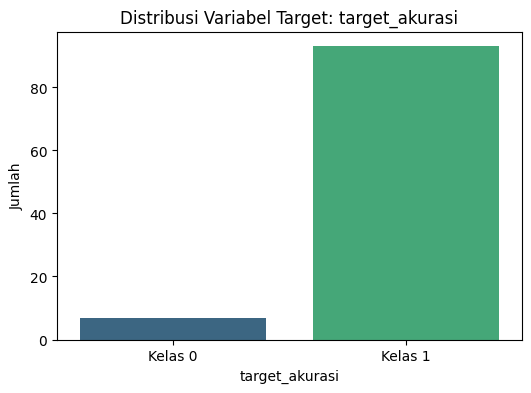

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Distribusi Variabel Target: target_akurasi')
plt.xlabel('target_akurasi')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Kelas 0', 'Kelas 1'])
plt.show()

## 4. Train-Test Split

Membagi data menjadi set pelatihan (80%) dan set pengujian (20%) dengan `random_state=42` untuk reproduktifitas.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran data training: {X_train.shape[0]} samples")
print(f"Ukuran data testing: {X_test.shape[0]} samples")
print(f"Distribusi kelas di data training:\n{y_train.value_counts(normalize=True)}")
print(f"Distribusi kelas di data testing:\n{y_test.value_counts(normalize=True)}")

Ukuran data training: 80 samples
Ukuran data testing: 20 samples
Distribusi kelas di data training:
target_akurasi
1    0.925
0    0.075
Name: proportion, dtype: float64
Distribusi kelas di data testing:
target_akurasi
1    0.95
0    0.05
Name: proportion, dtype: float64


## 5. Pelatihan Model Logistic Regression dengan `class_weight='balanced'`

Melatih model Logistic Regression dengan parameter `class_weight='balanced'` untuk mengatasi *imbalance data*.

In [ ]:
model = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear') # solver='liblinear' cocok untuk dataset kecil
model.fit(X_train, y_train)

print("Model Logistic Regression telah dilatih dengan class_weight='balanced'.")

Model Logistic Regression telah dilatih dengan class_weight='balanced'.


## 6. Evaluasi Model

Menghitung dan menampilkan `Accuracy Score`, `Confusion Matrix`, dan `Classification Report`.


--- Hasil Evaluasi Model ---
Accuracy Score: 0.7500

Confusion Matrix:
[[ 1  0]
 [ 5 14]]


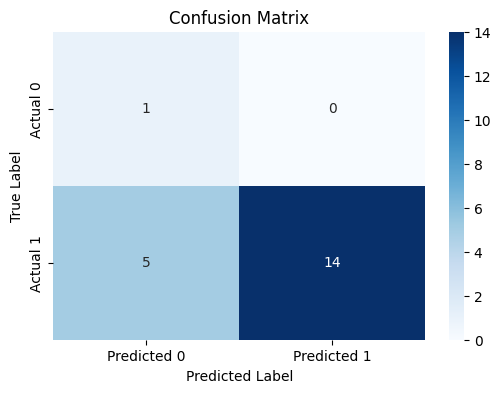


Classification Report:
              precision    recall  f1-score   support

           0       0.17      1.00      0.29         1
           1       1.00      0.74      0.85        19

    accuracy                           0.75        20
   macro avg       0.58      0.87      0.57        20
weighted avg       0.96      0.75      0.82        20



In [ ]:
y_pred = model.predict(X_test)

print("\n--- Hasil Evaluasi Model ---")

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)